# 暂退法

经典泛化理论认为,为了缩小训练和测试性能之间的差距,应该以简单的模型为目标

简单性的另一个角度是平滑性,即函数不应该对其输入的微小变化敏感

应用于网络的内部层提出了一个想法:在训练过程中,他们建议在计算后续层之前向网络的每一层注入噪声。
因为当训练一个有多层的深层网络时,注入噪声只会在输入‐输出映射上增强平滑性。这个想法被称为暂退法(dropout)

暂退法在前向传播过程中,计算每一内部层的同时注入噪声,这已经成为训练神经网络的常用技术。
这种方法之所以被称为暂退法,因为我们从表面上看是在训练过程中丢弃(drop  out)一些神经元。
在整个训练过程的每一次迭代中,标准暂退法包括在计算下一层之前将当前层中的一些节点置零

## 关键的挑战就是如何注入这种噪声

一种想法是以一种无偏向(unbiased)的方式注入噪声。这样在固  定住其他层时,每一层的期望值等于没有噪音时的值

Dropout（暂退法） 是最简单、最有效的正则化技术之一，它的核心思想是：

在训练时随机“丢弃”一部分神经元，迫使模型不能过度依赖任何一个神经元，从而提高模型的泛化能力。

## 从零开始实现

In [11]:
import torch
from torch import nn
from d2l import torch as d2l

def dropout_layer(X, dropout):
    """
    从零实现 Dropout 层
    X: 输入张量
    dropout: 丢弃概率（即神经元被设为 0 的概率）
    """
    # 1. 检查丢弃概率是否在合法范围内 [0, 1]
    assert 0 <= dropout <= 1

    # 2. 特殊情况处理：全部丢弃
    if dropout == 1:
        return torch.zeros_like(X)

    # 3. 特殊情况处理：全部保留
    if dropout == 0:
        return X

    # 4. 核心逻辑：生成掩码 (Mask)
    # torch.rand 生成 [0, 1) 之间的均匀分布随机数
    # 如果随机数 > dropout，则保留（为 1），否则丢弃（为 0）
    mask = (torch.rand(X.shape) > dropout).float()

    # 5. 返回结果：应用掩码并进行“缩放”
    # 为什么要除以 (1.0 - dropout)？
    # 为了保证在训练和测试时，神经元输出的【期望值】保持不变（Inverted Dropout）
    return mask * X / (1.0 - dropout)

模型参数

In [12]:
# 假设输入 784 (MNIST), 输出 10, 隐藏层分别是 256, 256
num_inputs, num_outputs, num_hiddens1, num_hiddens2 = 784, 10, 256, 256

### 定义模型

In [13]:
#设置丢弃概率
dropout1, dropout2 = 0.2, 0.5

class Net(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens1, num_hiddens2, is_training=True):
        super(Net, self).__init__()
        self.num_inputs = num_inputs
        self.training = is_training  # 手动控制是否处于训练模式

        # 定义三层线性层
        self.lin1 = nn.Linear(num_inputs, num_hiddens1)
        self.lin2 = nn.Linear(num_hiddens1, num_hiddens2)
        self.lin3 = nn.Linear(num_hiddens2, num_outputs)
        self.relu = nn.ReLU()

    def forward(self, X):
        # 1. 输入层 -> 第一隐藏层 -> ReLU
        H1 = self.relu(self.lin1(X.reshape((-1, self.num_inputs))))

        # 只有在训练时才应用 Dropout
        if self.training == True:
            # 在第一个全连接层之后添加 Dropout
            H1 = dropout_layer(H1, dropout1)

        # 2. 第一隐藏层 -> 第二隐藏层 -> ReLU
        H2 = self.relu(self.lin2(H1))

        if self.training == True:
            # 在第二个全连接层之后添加 Dropout
            H2 = dropout_layer(H2, dropout2)

        # 3. 输出层
        out = self.lin3(H2)
        return out

# 实例化模型

net = Net(num_inputs, num_outputs, num_hiddens1, num_hiddens2)

##训练和测试

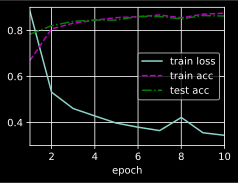

In [14]:
from train_ch3 import train_ch3
num_epochs, lr, batch_size = 10, 0.5, 256
loss = nn.CrossEntropyLoss(reduction='none')
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
trainer = torch.optim.SGD(net.parameters(), lr=lr)
#d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

##简洁实现

In [15]:
# 0. 预设丢弃概率
dropout1, dropout2 = 0.2, 0.5

# 1. 定义模型：简洁的顺序容器实现
net = nn.Sequential(
    nn.Flatten(),                # 将图片展平为一维向量 (784)
    nn.Linear(784, 256),         # 第一层全连接
    nn.ReLU(),                   # 激活函数
    nn.Dropout(dropout1),        # 在第一层后添加 Dropout 层

    nn.Linear(256, 256),         # 第二层全连接
    nn.ReLU(),                   # 激活函数
    nn.Dropout(dropout2),        # 在第二层后添加 Dropout 层

    nn.Linear(256, 10)           # 输出层
)

# 2. 定义初始化权重的函数
def init_weights(m):
    # 只对线性层进行初始化
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01) # 权重设为均值0，标准差0.01的正态分布
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)     # 偏置项设为 0

# 3. 将初始化函数应用到整个网络上
net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): ReLU()
  (6): Dropout(p=0.5, inplace=False)
  (7): Linear(in_features=256, out_features=10, bias=True)
)

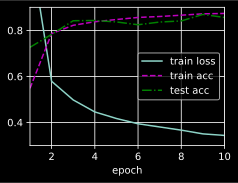

In [16]:
trainer = torch.optim.SGD(net.parameters(), lr=lr)
#d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

• 暂退法在前向传播过程中,计算每一内部层的同时丢弃一些神经元。

• 暂退法可以避免过拟合,它通常与控制权重向量的维数和大小结合使用的。

• 暂退法将活性值h替换为具有期望值h的随机变量。

• 暂退法仅在训练期间使用。